In [1]:
import os
import pandas as pd

In [2]:
methods_names = {
    "dist_linguistic_confidence": "Hedged QA",
    "dist_lnll": "Direct QA"
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuADv2.0",
    "trivia_qa": "TriviaQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
}

In [3]:
results_dir = f"/hdd/ivny/linguistic_confidence_prompt_test"

# list all leaf nodes in results_dir
leaf_dirs = []
for root, dirs, files in os.walk(results_dir):
    if not dirs:  # if there are no subdirectories, it's a leaf node
        leaf_dirs.append(root)

all_records = []
for leaf_dir in leaf_dirs:
    try:
        _, _, _, _, dataset_name, estimation_method, _, model_name = leaf_dir.split("/")
        csv_data = pd.read_csv(os.path.join(leaf_dir, "linguistic_confidence.csv"))[["linguistic_confidence_mean"]]
        df_dict = {
            "Dataset": dataset_map[dataset_name],
            "Est. Method": methods_names[estimation_method],
            "Model": model_name_map[model_name],
            "Confidence": csv_data["linguistic_confidence_mean"].tolist()
        }
        all_records.append(df_dict)
    except Exception as e:
        print(f"Error processing {leaf_dir}: {e}")

full_df = pd.DataFrame(all_records)

In [4]:
paired_df = (
    full_df
    .pivot(index=["Dataset", "Model"], 
           columns="Est. Method", 
           values="Confidence")
    .reset_index()
)

paired_df.dropna(inplace=True)
paired_df

Est. Method,Dataset,Model,Direct QA,Hedged QA
0,MMLU,GPT-OSS-20B,"[0.6722222222222222, 0.5444444444444445, 0.616...","[0.9033333333333332, 0.85, 0.3922222222222222,..."
1,MMLU,Llama-3-8B-Inst.,"[0.6966666666666667, 0.7000000000000001, 0.641...","[0.8433333333333333, 0.9377777777777776, 0.612..."
2,MMLU,Llama-3.1-8B-Inst.,"[0.6000000000000001, 0.6077777777777779, 0.617...","[0.5377777777777778, 0.4955555555555555, 0.855..."
3,MMLU,Mistral-7B-Inst.,"[0.6888888888888889, 0.66, 0.6877777777777777,...","[0.7977777777777778, 0.8844444444444445, 0.734..."
4,MMLU,Qwen2.5-7B-Inst.,"[0.6888888888888889, 0.6699999999999999, 0.549...","[0.4911111111111111, 0.4822222222222222, 0.713..."
5,MMLU,Qwen3-8B-Inst.,"[0.6722222222222222, 0.6822222222222222, 0.653...","[0.8999999999999999, 0.5188888888888888, 0.602..."
6,SQuADv2.0,GPT-OSS-20B,"[0.9733333333333332, 0.9422222222222224, 0.882...","[0.9333333333333332, 0.9166666666666666, 0.923..."
7,SQuADv2.0,Llama-3-8B-Inst.,"[0.9844444444444445, 0.7111111111111111, 0.930...","[0.999999, 0.9577777777777776, 0.8211111111111..."
8,SQuADv2.0,Llama-3.1-8B-Inst.,"[0.8966666666666667, 0.7333333333333333, 0.8, ...","[0.9611111111111112, 0.8588888888888889, 0.867..."
9,SQuADv2.0,Mistral-7B-Inst.,"[0.9811111111111112, 0.8433333333333333, 0.871...","[0.9866666666666666, 0.9388888888888888, 0.845..."


In [5]:
paired_df = paired_df.explode(list(paired_df.columns[2:]))
paired_df

Est. Method,Dataset,Model,Direct QA,Hedged QA
0,MMLU,GPT-OSS-20B,0.672222,0.903333
0,MMLU,GPT-OSS-20B,0.544444,0.85
0,MMLU,GPT-OSS-20B,0.616667,0.392222
0,MMLU,GPT-OSS-20B,0.646667,0.705556
0,MMLU,GPT-OSS-20B,0.627778,0.846667
...,...,...,...,...
17,TriviaQA,Qwen3-8B-Inst.,0.927778,0.858889
17,TriviaQA,Qwen3-8B-Inst.,0.502222,0.738889
17,TriviaQA,Qwen3-8B-Inst.,0.866667,0.865556
17,TriviaQA,Qwen3-8B-Inst.,0.761111,0.868889


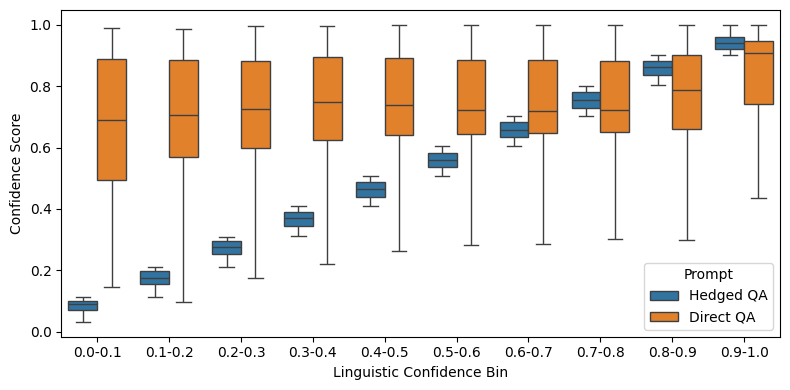

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETERS
# -----------------------------
n_bins = 10  # number of bins for Ling. Conf
min_points = 1  # minimum responses per bin

# -----------------------------
# 1. BIN BY DIST. LING. CONF. ONLY
# -----------------------------
paired_df["A_bin"] = pd.cut(
    paired_df["Hedged QA"],
    bins=n_bins
)

# -----------------------------
# 2. FILTER SPARSE BINS
# -----------------------------
bin_counts = paired_df["A_bin"].value_counts()
valid_bins = bin_counts[bin_counts >= min_points].index
filtered_df = paired_df[paired_df["A_bin"].isin(valid_bins)].copy()

# -----------------------------
# 3. CONVERT TO LONG FORMAT (POOL ALL MODELS)
# Convert bin intervals to their left edge values
# -----------------------------
filtered_df["bin_value"] = filtered_df["A_bin"].apply(lambda x: x.left)

long_df = pd.DataFrame({
    "A_bin": np.concatenate([filtered_df["bin_value"], filtered_df["bin_value"]]),
    "Confidence": np.concatenate([filtered_df["Hedged QA"], filtered_df["Direct QA"]]),
    "Prompt": ["Hedged QA"]*len(filtered_df) + ["Direct QA"]*len(filtered_df)
})

# -----------------------------
# 4. PLOT BOXPLOTS
# -----------------------------
plt.figure(figsize=(8,4))
sns.boxplot(
    data=long_df,
    x="A_bin",
    y="Confidence",
    hue="Prompt",
    showfliers=False
)

# Set x-axis ticks to show 0-0.1, 0.1-0.2, ..., 0.9-1
bin_labels = [f"{i/n_bins:.1f}-{(i+1)/n_bins:.1f}" for i in range(n_bins)]
plt.xticks(range(n_bins), bin_labels, rotation=0)
plt.xlabel("Linguistic Confidence Bin")
plt.ylabel("Confidence Score")
# plt.title("Confidence Distributions per Ling. Conf. Bin (Models Averaged)")
plt.legend(title="Prompt")
plt.tight_layout()
plt.savefig("linguistic_confidence_prompts_compare.pdf", bbox_inches='tight', dpi=300)